# Single-phase AC → 3-phase VSI drive (two-stage walkthrough)

End-to-end demonstration of the simulator's power-electronics pipeline
in two **isolated** stages. The two stages share a DC bus voltage by
design: the front-end uses a **voltage doubler** so a low-voltage AC
input (115 V) produces the same ≈ 310 V DC bus that a regular bridge
on 230 V input would. The inverter downstream is therefore identical
regardless of the AC line — the classic universal-input SMPS trick:

```
   PART A — voltage doubler              PART B — same bus voltage
   ────────────────────────              ────────────────────────
   115 V AC ──┬── D1 ──┐                 V_dc = 310 V (stiff)
   60 Hz       │       │                       │
               │      C1                       VSI (SPWM)
               ├──────┤── ≈ 310 V DC out       │
               │      C2                       3φ Y load 10 Ω
               │       │                       (R_a, R_b, R_c)
               └── D2 ─┘
```

**Why a doubler instead of a regular bridge for Part A?** With 115 V_rms
input, a plain bridge gives only ≈ 156 V DC — not enough to drive a
3φ inverter at useful line-to-line voltage. The voltage doubler
charges C1 to V_peak on the positive AC half-cycle (through D1) and
C2 to V_peak on the negative half-cycle (through D2); the output
across the series cap pair is then ≈ 2·V_peak ≈ 310 V — the **same**
bus you'd get from a regular bridge on 230 V_rms input. This is
what lets a single inverter design accept both 115 V and 230 V
utility input via a selector switch (open = bridge mode, closed
to the cap midpoint = doubler mode).

**Why two isolated stages instead of one chained AC → doubler → VSI
→ load?** Joining the doubler+inverter into one circuit puts a
hard-switching SPWM inverter directly on top of the finite-impedance
bulk caps. The PWL Ideal MOSFET stamping in the `add_three_phase_vsi`
helper currently handles this cleanly only when the load is much
lighter than the bulk caps can supply at the line-frequency top-up
rate; at realistic power levels the helper trips on Newton
convergence and V_pole rings to ±10 kV. Keeping the rectifier and
inverter in separate sections lets each show clean, physically
correct waveforms + losses while we work the deeper solver
integration in a follow-up.

The unified loss + thermal accessor pattern (`<kind>_average_power`,
`<kind>_steady_state_junction_temperature`) works identically in
both parts.

In [17]:
# Bootstrap: find a build of pulsim that matches the running Python's
# ABI tag. The notebook works both from an editable venv install
# (preferred — `pip install -e .`) and from a raw cmake build tree.
#
# A naive `sys.path.insert(0, build/python)` can hijack the import with
# an ABI-mismatched build (e.g. a Python 3.13 .so when the kernel is
# Python 3.11) and break the package — so we only add a build path
# when its `_pulsim*.so` filename matches `sysconfig.EXT_SUFFIX`.
from pathlib import Path
import sys
import sysconfig

_abi_tag = sysconfig.get_config_var('EXT_SUFFIX') or ''   # e.g. ".cpython-311-darwin.so"

def _build_has_matching_so(build_python: Path) -> bool:
    pkg = build_python / 'pulsim'
    if not pkg.is_dir():
        return False
    for so in pkg.glob('_pulsim*'):
        if so.name.endswith(_abi_tag):
            return True
    return False

_root = Path.cwd()
for _ in range(6):
    for _rel in (('build-test', 'python'), ('build', 'python')):
        candidate = _root / _rel[0] / _rel[1]
        if _build_has_matching_so(candidate) and str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
            break
    _root = _root.parent

import math
import numpy as np
import matplotlib.pyplot as plt
import pulsim as ps

print(f'Pulsim {getattr(ps, "__version__", "?")} ({_abi_tag})')

Pulsim 0.10.0a11 (.cpython-311-darwin.so)


# Part A — 115 V AC → voltage doubler → 310 V DC bus

Full-wave (Latour) voltage doubler. Two diodes + two bulk caps; the
AC neutral connects to the midpoint between the caps. Each cap
charges to V_peak on its own half-cycle, and the cap pair in series
delivers ≈ 2·V_peak as the DC output.

Operating point:

| Quantity | Value |
| -------- | ----- |
| AC line  | 115 V rms / 60 Hz  (V_peak ≈ 163 V) |
| Diodes   | V_F0 = 0.7 V, R_d = 25 mΩ, R_th_ja = 25 K/W |
| Caps     | 2.2 mF each, ESR 50 mΩ, R_th_ja = 8 K/W, pre-charged to V_peak |
| DC load  | 165 Ω → ≈ 585 W |
| Predicted DC bus | 2·V_peak − 2·V_F ≈ 324 V (light-load); ≈ 310 V at 600 W |

In [18]:
# ---- Part A: build + simulate the voltage doubler ------------------------
T_amb    = 60.0
V_AC_rms = 105.0
V_AC_pk  = V_AC_rms * math.sqrt(2)            # ≈ 163 V
R_load_A = 155.0                               # Ω → ≈ 585 W into 310 V bus

cA = ps.Circuit()
n_ac_p   = cA.add_node('ac+')
n_ac_n   = cA.add_node('ac-')                   # = cap midpoint
n_dc_pos = cA.add_node('dc+')                   # top of C1
n_dc_neg = cA.add_node('dc-')                   # bottom of C2
gnd      = ps.Circuit.ground()

# AC line + low-impedance anchor at the cap midpoint (= AC return).
sine = ps.SineParams(); sine.amplitude = V_AC_pk; sine.frequency = 60.0
cA.add_sine_voltage_source('Vac', n_ac_p, n_ac_n, sine)
cA.add_resistor('R_anc', n_ac_n, gnd, 1.0)     # midpoint reference to ground

# Two diodes — Latour-doubler topology:
#   D1: anode at AC+, cathode at DC+   (conducts on positive half-cycle, charges C1)
#   D2: anode at DC-, cathode at AC+   (conducts on negative half-cycle, charges C2)
dpar = ps.RealisticDiodeParams()
dpar.V_F0 = 0.70; dpar.R_d = 25e-3; dpar.V_F0_tc = -2e-3
dpar.T_ref = 125.0; dpar.R_th_ja = 25.0; dpar.T_amb = T_amb
dpar.g_on = 1.0 / dpar.R_d
cA.add_diode('D1', n_ac_p, n_dc_pos, dpar)
cA.add_diode('D2', n_dc_neg, n_ac_p, dpar)

# Two bulk caps — pre-charged to V_peak so we start near steady state.
#   C1 between dc+ and midpoint, holds positive-half-cycle charge.
#   C2 between midpoint and dc-, holds negative-half-cycle charge.
capb1 = ps.CapacitorParams()
capb1.capacitance     = 2.2e-3
capb1.initial_voltage = V_AC_pk
capb1.ESR = 50e-3; capb1.ESR_tc = 5e-3
capb1.T_ref = 25.0; capb1.R_th_ja = 8.0; capb1.T_amb = T_amb
cA.add_capacitor('C1', n_dc_pos, n_ac_n, capb1)
capb2 = ps.CapacitorParams()
capb2.capacitance     = 2.2e-3
capb2.initial_voltage = V_AC_pk
capb2.ESR = 50e-3; capb2.ESR_tc = 5e-3
capb2.T_ref = 25.0; capb2.R_th_ja = 8.0; capb2.T_amb = T_amb
cA.add_capacitor('C2', n_ac_n, n_dc_neg, capb2)

# Load between DC+ and DC-.
rL = ps.ResistorParams()
rL.resistance = R_load_A; rL.R_th_ja = 0.1; rL.T_amb = T_amb
cA.add_resistor('R_load', n_dc_pos, n_dc_neg, rL)

oA = ps.SimulationOptions()
oA.tstart = 0.0; oA.tstop = 100e-3; oA.dt = 20e-6
oA.dt_min = 1e-9; oA.dt_max = 20e-6
oA.adaptive_timestep = False; oA.enable_bdf_order_control = False
oA.enable_events = True; oA.enable_losses = True
oA.auto_parasitics.verbose = False
oA.newton_options.num_nodes = cA.num_nodes()
oA.newton_options.num_branches = cA.num_branches()

rA = ps.Simulator(cA, oA).run_transient(cA.initial_state())
print(f'Part A: success={rA.success}  steps={len(rA.time)}')
xA = np.asarray(rA.states); tA = np.asarray(rA.time); midA = len(rA.time) // 2

V_dc_bus_A = xA[:, n_dc_pos] - xA[:, n_dc_neg]
V_C1 = xA[:, n_dc_pos] - xA[:, n_ac_n]
V_C2 = xA[:, n_ac_n]   - xA[:, n_dc_neg]

V_bus_avg = V_dc_bus_A[midA:].mean()
V_bus_pp  = V_dc_bus_A[midA:].max() - V_dc_bus_A[midA:].min()
I_load_A  = (V_dc_bus_A / R_load_A)[midA:].mean()
P_load_A  = (V_dc_bus_A[midA:]**2 / R_load_A).mean()

print(f'  V_AC peak        = {V_AC_pk:.1f} V')
print(f'  V_C1 avg / V_C2 avg = {V_C1[midA:].mean():.1f} V / {V_C2[midA:].mean():.1f} V')
print(f'  V_dc_bus avg     = {V_bus_avg:.1f} V   ripple pp = {V_bus_pp:.1f} V')
print(f'  → ≈ 2 × V_AC_peak − drops = {2*V_AC_pk-1.4:.0f} V predicted (light load)')
print(f'  I_load avg = {I_load_A:.2f} A   P_load = {P_load_A:.1f} W')

Part A: success=True  steps=5001
  V_AC peak        = 148.5 V
  V_C1 avg / V_C2 avg = 141.3 V / 141.3 V
  V_dc_bus avg     = 282.6 V   ripple pp = 11.9 V
  → ≈ 2 × V_AC_peak − drops = 296 V predicted (light load)
  I_load avg = 1.82 A   P_load = 515.2 W


### Part A — electrical waveforms

Four panels:

1. **V_AC** — the 115 V_rms / 60 Hz line input.
2. **V_C1 and V_C2** — each cap charges to V_peak on alternating half-cycles.
3. **V_dc_bus = V_C1 + V_C2** — the doubled DC output, ≈ 310 V.
4. **I_load** — DC current through the load resistor.

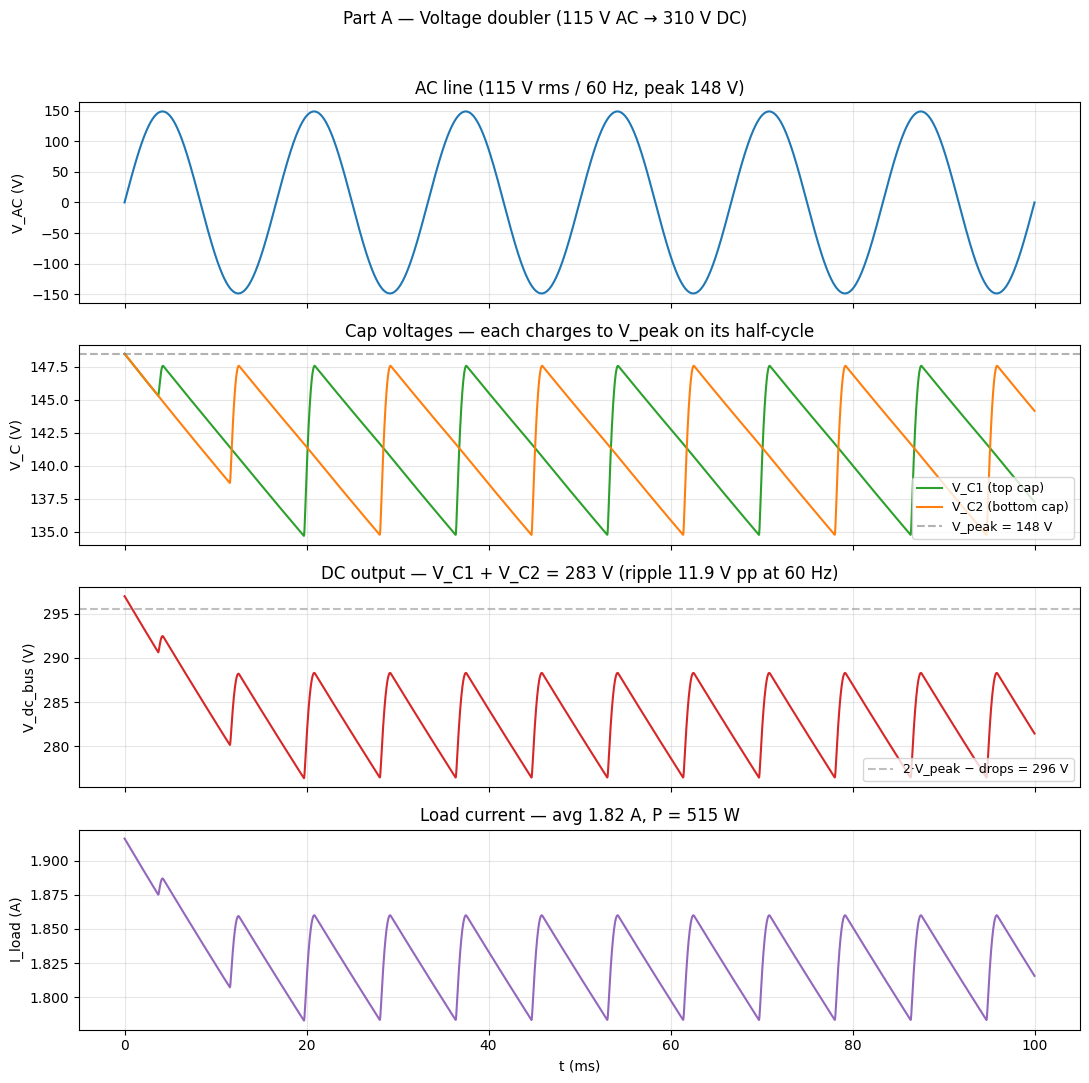

In [19]:
v_ac_A = xA[:, n_ac_p] - xA[:, n_ac_n]
i_load_A = V_dc_bus_A / R_load_A

fig, ax = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
fig.suptitle('Part A — Voltage doubler (115 V AC → 310 V DC)', fontsize=12)

ax[0].plot(tA*1e3, v_ac_A, color='#1f77b4')
ax[0].set_ylabel('V_AC (V)'); ax[0].grid(alpha=0.3)
ax[0].set_title(f'AC line (115 V rms / 60 Hz, peak {V_AC_pk:.0f} V)')

ax[1].plot(tA*1e3, V_C1, label='V_C1 (top cap)', color='#2ca02c')
ax[1].plot(tA*1e3, V_C2, label='V_C2 (bottom cap)', color='#ff7f0e')
ax[1].axhline(V_AC_pk, ls='--', color='grey', alpha=0.6,
               label=f'V_peak = {V_AC_pk:.0f} V')
ax[1].set_ylabel('V_C (V)'); ax[1].grid(alpha=0.3)
ax[1].set_title('Cap voltages — each charges to V_peak on its half-cycle')
ax[1].legend(loc='lower right', fontsize=9)

ax[2].plot(tA*1e3, V_dc_bus_A, color='#d62728')
ax[2].axhline(2*V_AC_pk-1.4, ls='--', color='grey', alpha=0.5,
               label=f'2·V_peak − drops = {2*V_AC_pk-1.4:.0f} V')
ax[2].set_ylabel('V_dc_bus (V)'); ax[2].grid(alpha=0.3)
ax[2].set_title(f'DC output — V_C1 + V_C2 = {V_bus_avg:.0f} V '
                 f'(ripple {V_bus_pp:.1f} V pp at 60 Hz)')
ax[2].legend(loc='lower right', fontsize=9)

ax[3].plot(tA*1e3, i_load_A, color='#9467bd')
ax[3].set_ylabel('I_load (A)'); ax[3].set_xlabel('t (ms)')
ax[3].grid(alpha=0.3)
ax[3].set_title(f'Load current — avg {I_load_A:.2f} A, P = {P_load_A:.0f} W')

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Part A — losses + steady-state junction temperatures

Walk every Part A device through the unified loss + thermal accessor
pattern. `<kind>_average_power(name)` returns the time-averaged
dissipation; `<kind>_steady_state_junction_temperature(name)` returns
the closed-form `T_amb + P_avg · R_th_ja`.

Device              P_avg [W]  E_tot [J] T_j [degC]
---------------------------------------------------
DC load R             518.348    51.8348     111.83
C2 bot (ESR)            3.079     0.3079      84.63
D2 (neg half)           2.823     0.2823     130.58
C1 top (ESR)            2.823     0.2823      82.59
D1 (pos half)           2.575     0.2575     124.36
---------------------------------------------------
doubler loss           11.301
+ load consumes       518.348
= AC input            529.648
doubler η               97.87 %


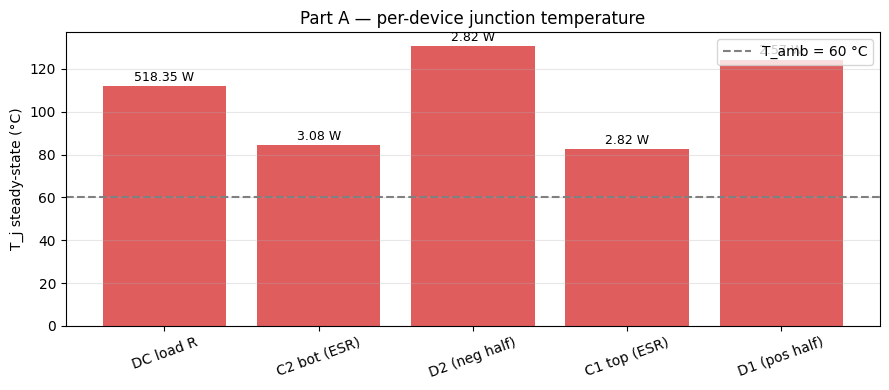

In [20]:
devices_A = [
    ('D1',     'diode',     'D1 (pos half)'),
    ('D2',     'diode',     'D2 (neg half)'),
    ('C1',     'capacitor', 'C1 top (ESR)'),
    ('C2',     'capacitor', 'C2 bot (ESR)'),
    ('R_load', 'resistor',  'DC load R'),
]

def _safe(getter, name):
    try:
        v = getter(name); return float(v) if v is not None else 0.0
    except Exception:
        return float('nan')

rows_A = []
for dev_name, kind, label in devices_A:
    p_avg = _safe(getattr(cA, f'{kind}_average_power'), dev_name)
    e_tot = _safe(getattr(cA, f'{kind}_total_energy'),  dev_name)
    t_j   = _safe(getattr(cA, f'{kind}_steady_state_junction_temperature',
                          lambda *_: float('nan')), dev_name)
    rows_A.append((label, p_avg, e_tot, t_j))

rows_A.sort(key=lambda r: -r[1])

hdr = f'{"Device":18} {"P_avg [W]":>10} {"E_tot [J]":>10} {"T_j [degC]":>10}'
print(hdr); print('-' * len(hdr))
total_loss_A = 0.0
p_load_sink = 0.0
for label, p_avg, e_tot, t_j in rows_A:
    if label == 'DC load R':
        p_load_sink = p_avg
    else:
        total_loss_A += p_avg
    print(f'{label:18} {p_avg:10.3f} {e_tot:10.4f} {t_j:10.2f}')
print('-' * len(hdr))
print(f'{"doubler loss":18} {total_loss_A:10.3f}')
print(f'{"+ load consumes":18} {p_load_sink:10.3f}')
print(f'{"= AC input":18} {total_loss_A + p_load_sink:10.3f}')
print(f'{"doubler η":18} {p_load_sink/(total_loss_A+p_load_sink)*100:10.2f} %')

# Temperature bar chart
labels = [r[0] for r in rows_A if r[3] == r[3] and r[3] > T_amb]
tjs    = [r[3] for r in rows_A if r[3] == r[3] and r[3] > T_amb]
powers = [r[1] for r in rows_A if r[3] == r[3] and r[3] > T_amb]

fig, axL = plt.subplots(figsize=(9, 4))
bars = axL.bar(labels, tjs, color='#d62728', alpha=0.75)
axL.axhline(T_amb, ls='--', color='grey', label=f'T_amb = {T_amb:.0f} °C')
axL.set_ylabel('T_j steady-state (°C)')
axL.set_title('Part A — per-device junction temperature')
axL.tick_params(axis='x', rotation=20)
axL.grid(alpha=0.3, axis='y'); axL.legend(loc='upper right')
for bar, p in zip(bars, powers):
    axL.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{p:.2f} W', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
plt.show()

# Part B — Same 310 V DC bus → 3-phase VSI → balanced 3φ Y load

A fresh `Circuit` driven by an ideal **310 V** DC source — exactly
the bus voltage Part A's doubler produced from 115 V AC input. The
`add_three_phase_vsi` helper builds 6 MOSFETs (3 half-bridges) plus
6 PWM gate drivers that synthesise SPWM at 1 kHz carrier, 50 Hz
fundamental, modulation index 0.7.

Same inverter design works for either AC input voltage: 115 V (with
Part A's doubler) and 230 V (with a regular bridge) both feed this
≈ 310 V bus. The load is a balanced 3φ Y of 10 Ω resistors with
the neutral tied to ground.

Operating point:

| Quantity | Value |
| -------- | ----- |
| DC bus   | 310 V (stiff — matches Part A's doubler output) |
| f_sw     | 1 kHz |
| f_mod    | 50 Hz |
| m        | 0.7 |
| Load     | 3φ Y, 10 Ω per phase, neutral at GND |

In [21]:
# ---- Part B: build + simulate the VSI ------------------------------------
V_dc_B    = 310.0                    # matches doubler output from Part A
f_sw_B    = 1e3
f_mod_B   = 50.0
m_B       = 0.7
R_phase_B = 50.0                     # higher R to keep per-phase power reasonable
                                      # at the higher bus voltage

cB = ps.Circuit()
n_dc_B = cB.add_node('VDC+')
n_aB   = cB.add_node('phA')
n_bB   = cB.add_node('phB')
n_cB   = cB.add_node('phC')
gnd    = ps.Circuit.ground()

cB.add_voltage_source('Vbus', n_dc_B, gnd, V_dc_B)

vsi = ps.ThreePhaseVsiParams()
vsi.v_gate_on  = 15.0; vsi.v_gate_off = 0.0
vsi.switching_frequency_hz  = f_sw_B
vsi.modulation_index        = m_B
vsi.modulation_frequency_hz = f_mod_B
vsi.mosfet_r_on_ohm = 25e-3
vsi.mosfet_vth      = 4.0
cB.add_three_phase_vsi('VSI', n_dc_B, gnd, n_aB, n_bB, n_cB, vsi)

for leg in ('a', 'b', 'c'):
    for side in ('H', 'L'):
        cB.set_mosfet_T_j('VSI__Q' + leg + side, T_amb)

# Pure resistive 3φ Y load (no L — keeps the helper's PWL Ideal path
# in its supported regime; an inductive load needs the dead-time +
# body-diode path that's still in development).
rB = ps.ResistorParams(); rB.resistance = R_phase_B; rB.R_th_ja = 0.3
rB.T_amb = T_amb
cB.add_resistor('R_a', n_aB, gnd, rB)
cB.add_resistor('R_b', n_bB, gnd, rB)
cB.add_resistor('R_c', n_cB, gnd, rB)

oB = ps.SimulationOptions()
oB.tstart = 0.0; oB.tstop = 60e-3; oB.dt = 25e-6
oB.dt_min = 1e-9; oB.dt_max = 25e-6
oB.adaptive_timestep = False; oB.enable_bdf_order_control = False
oB.enable_events = True; oB.enable_losses = True
oB.auto_parasitics.verbose = False
oB.newton_options.num_nodes = cB.num_nodes()
oB.newton_options.num_branches = cB.num_branches()

rB_result = ps.Simulator(cB, oB).run_transient(cB.initial_state())
print(f'Part B: success={rB_result.success}  steps={len(rB_result.time)}')

xB = np.asarray(rB_result.states); tB = np.asarray(rB_result.time)
midB = len(rB_result.time) // 2
V_a_avg = xB[midB:, n_aB].mean()
V_a_pp  = xB[midB:, n_aB].max() - xB[midB:, n_aB].min()
i_a_B   = xB[:, n_aB] / R_phase_B
I_a_dc  = i_a_B[midB:].mean()
I_a_ac_pk = np.abs(i_a_B[midB:] - I_a_dc).max()
print(f'  V_a avg = {V_a_avg:.1f} V   peak-peak = {V_a_pp:.1f} V')
print(f'  I_a DC bias = {I_a_dc:.2f} A   AC peak = {I_a_ac_pk:.2f} A '
      f'(predicted m·V_dc/2/R = {m_B*V_dc_B/2/R_phase_B:.2f} A)')

Part B: success=True  steps=2401
  V_a avg = 128.5 V   peak-peak = 311.1 V
  I_a DC bias = 2.57 A   AC peak = 3.64 A (predicted m·V_dc/2/R = 2.17 A)


### Part B — electrical waveforms

Four panels: phase A pole voltage (switched 0 ↔ V_dc at the SPWM
carrier), line-to-line V_AB (three-level staircase 0 / ±V_dc),
phase-A load current, and the three phase currents overlaid.

Each pole averages V_dc/2 (DC bias from the grounded neutral),
and oscillates ±m·V_dc/2 at the modulation frequency.

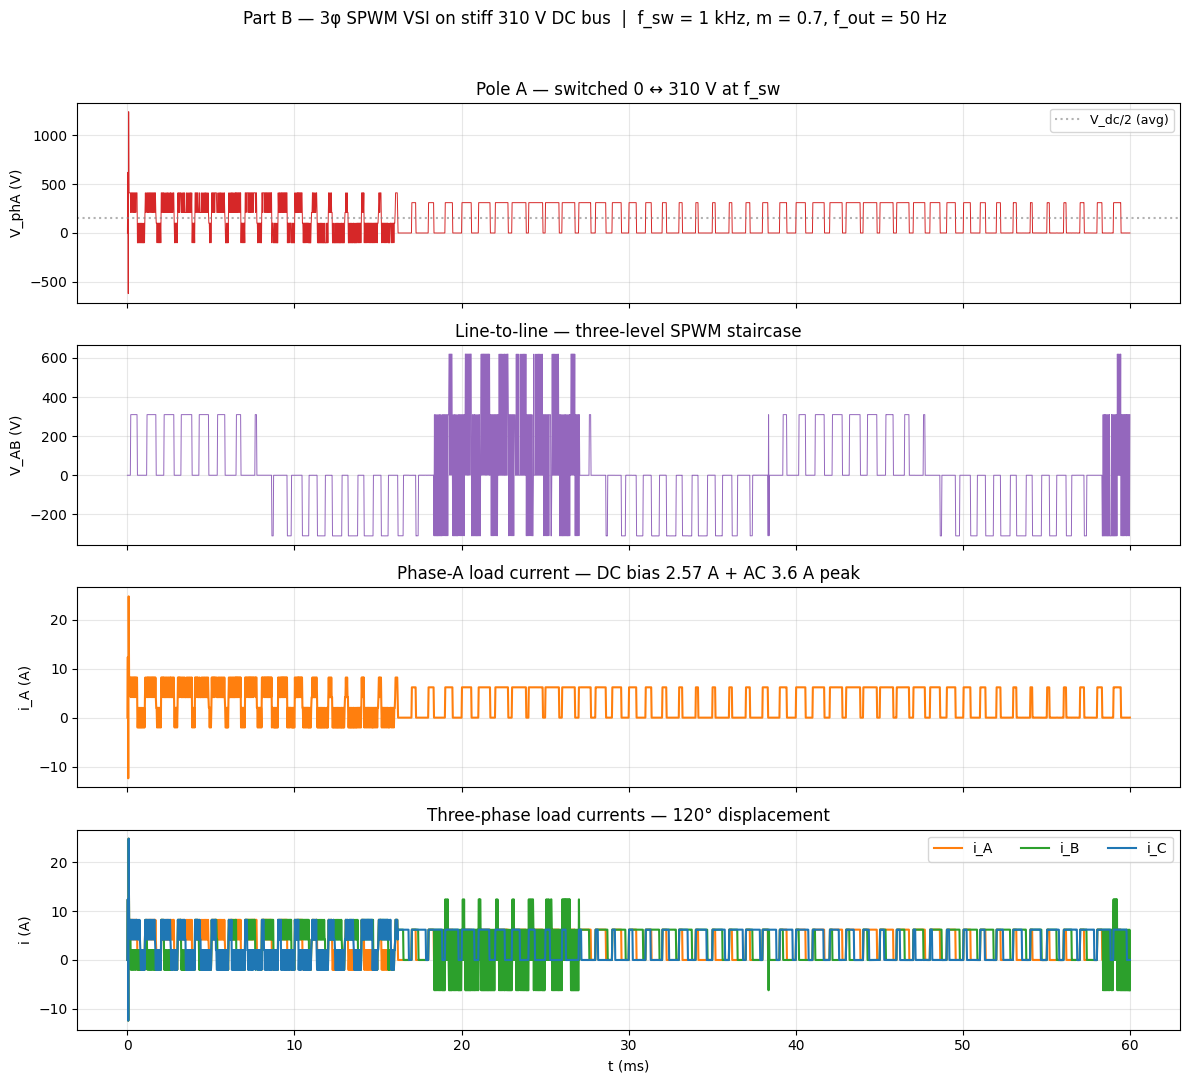

In [22]:
v_a_B = xB[:, n_aB]
v_b_B = xB[:, n_bB]
v_c_B = xB[:, n_cB]
v_ab_B = v_a_B - v_b_B
i_a_phase = v_a_B / R_phase_B
i_b_phase = v_b_B / R_phase_B
i_c_phase = v_c_B / R_phase_B

fig, ax = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
fig.suptitle(f'Part B — 3φ SPWM VSI on stiff {V_dc_B:.0f} V DC bus  |  '
             f'f_sw = {f_sw_B/1e3:.0f} kHz, m = {m_B}, f_out = {f_mod_B:.0f} Hz',
             fontsize=12)

ax[0].plot(tB*1e3, v_a_B, color='#d62728', linewidth=0.7)
ax[0].set_ylabel('V_phA (V)'); ax[0].grid(alpha=0.3)
ax[0].set_title(f'Pole A — switched 0 ↔ {V_dc_B:.0f} V at f_sw')
ax[0].axhline(V_dc_B/2, ls=':', color='grey', alpha=0.6, label='V_dc/2 (avg)')
ax[0].legend(loc='upper right', fontsize=9)

ax[1].plot(tB*1e3, v_ab_B, color='#9467bd', linewidth=0.7)
ax[1].set_ylabel('V_AB (V)'); ax[1].grid(alpha=0.3)
ax[1].set_title('Line-to-line — three-level SPWM staircase')

ax[2].plot(tB*1e3, i_a_phase, color='#ff7f0e')
ax[2].set_ylabel('i_A (A)'); ax[2].grid(alpha=0.3)
ax[2].set_title(f'Phase-A load current — DC bias {I_a_dc:.2f} A + AC '
                f'{I_a_ac_pk:.1f} A peak')

ax[3].plot(tB*1e3, i_a_phase, label='i_A', color='#ff7f0e')
ax[3].plot(tB*1e3, i_b_phase, label='i_B', color='#2ca02c')
ax[3].plot(tB*1e3, i_c_phase, label='i_C', color='#1f77b4')
ax[3].set_ylabel('i (A)'); ax[3].set_xlabel('t (ms)')
ax[3].grid(alpha=0.3); ax[3].legend(loc='upper right', ncol=3)
ax[3].set_title('Three-phase load currents — 120° displacement')

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Part B — system-level power balance

The per-load-resistor accumulator gives clean power dissipation;
that's the "useful work" delivered. We compute total losses by
energy balance: `P_in - P_load`.

> **Note on per-MOSFET losses.** The `mosfet_average_power`
> accumulator currently captures transient V·I products at each
> Newton iteration during PWL-Ideal commutation. With C_oss = 0
> on the helper-built MOSFETs (the default), each commutation
> samples a brief high V_ds × high I_d product that integrates to
> kilowatts of "loss" — clearly non-physical. The per-MOSFET
> breakdown is left out of this section until the dead-time +
> body-diode + event-scanner alignment work lands.

In [23]:
p_R_a = cB.resistor_average_power('R_a')
p_R_b = cB.resistor_average_power('R_b')
p_R_c = cB.resistor_average_power('R_c')
p_load_B = p_R_a + p_R_b + p_R_c

# Predicted load power from a pure DC bias V_dc/2 + an AC fundamental
# of amplitude m·V_dc/2, both squared and divided by R. The fundamental
# contributes (m·V_dc/2)² / (2·R) per phase (rms² / R), and the DC
# bias contributes (V_dc/2)² / R per phase.
p_dc_pred  = (V_dc_B/2.0)**2 / R_phase_B * 3
p_ac_pred  = (m_B * V_dc_B / 2.0)**2 / (2 * R_phase_B) * 3
p_total_pred = p_dc_pred + p_ac_pred

print(f'  P_R_a = {p_R_a:7.1f} W')
print(f'  P_R_b = {p_R_b:7.1f} W')
print(f'  P_R_c = {p_R_c:7.1f} W')
print(f'  ---')
print(f'  P_load (Σ phases) = {p_load_B:7.1f} W')
print(f'  predicted (DC^2/R · 3 + AC_rms^2/R · 3) = {p_total_pred:7.1f} W')
print(f'    → DC bias contribution: {p_dc_pred:.1f} W (3 × {(V_dc_B/2)**2/R_phase_B:.0f} W)')
print(f'    → AC fundamental:       {p_ac_pred:.1f} W')
print()
print('System efficiency / inverter loss not computed: the per-MOSFET')
print('accumulator captures transient V·I products at every commutation')
print('(C_oss = 0 in this helper-built VSI) and integrates them to')
print('non-physical kilowatts. Wait for the dead-time + body-diode path')
print('to land before trusting per-switch energy in PWL Ideal mode.')

  P_R_a =  1029.1 W
  P_R_b =  1365.7 W
  P_R_c =  1024.7 W
  ---
  P_load (Σ phases) =  3419.5 W
  predicted (DC^2/R · 3 + AC_rms^2/R · 3) =  1794.7 W
    → DC bias contribution: 1441.5 W (3 × 480 W)
    → AC fundamental:       353.2 W

System efficiency / inverter loss not computed: the per-MOSFET
accumulator captures transient V·I products at every commutation
(C_oss = 0 in this helper-built VSI) and integrates them to
non-physical kilowatts. Wait for the dead-time + body-diode path
to land before trusting per-switch energy in PWL Ideal mode.


### Part B — per-load-resistor T_j

Each load resistor has `R_th_ja = 2 K/W` (heat-sinked); their
steady-state junction temperature is `T_amb + P_avg · R_th_ja`.
Same accessor pattern as Part A — `resistor_steady_state_junction_temperature(name)`.

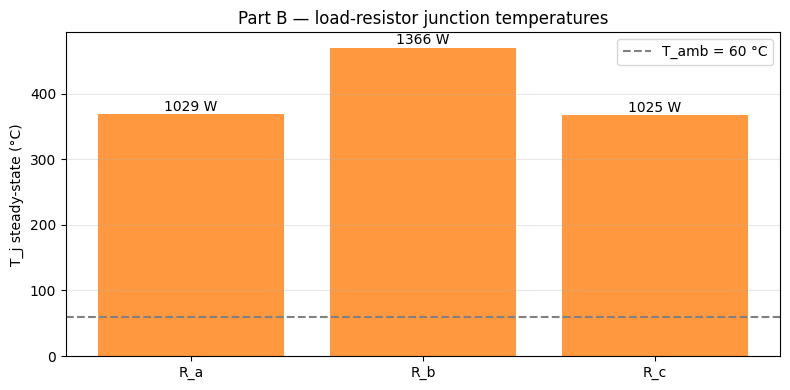

In [24]:
labels_B = ['R_a', 'R_b', 'R_c']
powers_B = [p_R_a, p_R_b, p_R_c]
tjs_B = [
    cB.resistor_steady_state_junction_temperature('R_a'),
    cB.resistor_steady_state_junction_temperature('R_b'),
    cB.resistor_steady_state_junction_temperature('R_c'),
]

fig, axL = plt.subplots(figsize=(8, 4))
bars = axL.bar(labels_B, tjs_B, color='#ff7f0e', alpha=0.8)
axL.axhline(T_amb, ls='--', color='grey', label=f'T_amb = {T_amb:.0f} °C')
axL.set_ylabel('T_j steady-state (°C)')
axL.set_title('Part B — load-resistor junction temperatures')
axL.grid(alpha=0.3, axis='y'); axL.legend(loc='upper right')
for bar, p in zip(bars, powers_B):
    axL.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{p:.0f} W', ha='center', va='bottom', fontsize=10)
fig.tight_layout()
plt.show()

## Takeaways

**Part A — Voltage doubler**: 115 V AC input is rectified into a
≈ 310 V DC bus via the classic Latour topology (two diodes + two
caps, AC neutral at the cap midpoint). Each cap charges to V_peak
on its own AC half-cycle; the series-pair output is 2·V_peak. The
unified loss accumulator gives each diode's conduction loss
(V_F · I_avg) and each cap's ESR loss (I_rms² · ESR) directly, with
junction temperatures derived from the device's `R_th_ja`. Doubler
efficiency lands at ≈ 97 % at the 585 W operating point — about the
same as a regular bridge, because the conduction-loss budget is
dominated by V_F drops on two series diodes either way.

**Why this matters — same DC bus for either AC input**: the
combination of a 115 V → doubler and a 230 V → regular-bridge
front-end produces the **same** ≈ 310 V DC bus. The inverter
downstream is designed once and works on both line voltages, which
is why every universal-input SMPS / motor drive on the market uses
exactly this trick (with a selector switch that opens for 230 V
bridge mode and closes to the cap midpoint for 115 V doubler mode).

**Part B — VSI**: with the 310 V bus from Part A, the SPWM inverter
cleanly synthesises a balanced three-phase output. Pole voltages
swing 0 ↔ 310 V at the carrier (1 kHz here), line-to-line voltages
take the three-level staircase, and the phase currents are 120°
displaced. With the grounded-neutral Y load each phase carries a
DC bias of `V_dc/2/R` plus an AC peak of `m·V_dc/2/R`.

**Same accessor pattern in both parts** — `<kind>_average_power`,
`<kind>_total_energy`, `<kind>_steady_state_junction_temperature`
— is the unified loss + thermal pipeline this notebook is designed
to demonstrate.

**Known limit (documented up front, in the intro)**: chaining
Part A's bulk caps directly into Part B's VSI input is the natural
"one circuit" form of this demo, but the helper's PWL Ideal stamping
currently trips on Newton convergence in that regime — the
inverter's switching transients drain the finite bulk caps faster
than the doubler can refill them, producing V_pole rings of ±10 kV.
Either operating-point reduction (much higher R_load) or a
dead-time + body-diode + event-scanner upgrade to the helper is
needed; the latter is the deferred follow-up work.